In [55]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [6]:
orders = r"/Users/sid/Downloads/orders.csv"
retail_orders = pd.read_csv(orders)

In [7]:
retail_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent'],
      dtype='object')

In [8]:
retail_orders.shape

(9994, 16)

In [9]:
retail_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order Id          9994 non-null   int64 
 1   Order Date        9994 non-null   object
 2   Ship Mode         9993 non-null   object
 3   Segment           9994 non-null   object
 4   Country           9994 non-null   object
 5   City              9994 non-null   object
 6   State             9994 non-null   object
 7   Postal Code       9994 non-null   int64 
 8   Region            9994 non-null   object
 9   Category          9994 non-null   object
 10  Sub Category      9994 non-null   object
 11  Product Id        9994 non-null   object
 12  cost price        9994 non-null   int64 
 13  List Price        9994 non-null   int64 
 14  Quantity          9994 non-null   int64 
 15  Discount Percent  9994 non-null   int64 
dtypes: int64(6), object(10)
memory usage: 1.2+ MB


In [10]:
retail_orders.head(5)

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [11]:
retail_orders.describe()

,Order Id,Postal Code,cost price,List Price,Quantity,Discount Percent
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,201.189714,229.756854,3.789574,3.484090
std,2885.163629,32063.693350,537.743203,623.245839,2.225110,1.114211
min,1.000000,1040.000000,0.000000,0.000000,1.000000,2.000000
25%,2499.250000,23223.000000,20.000000,20.000000,2.000000,2.000000
50%,4997.500000,56430.500000,50.000000,50.000000,3.000000,3.000000
75%,7495.750000,90008.000000,180.000000,210.000000,5.000000,4.000000
max,9994.000000,99301.000000,18110.000000,22640.000000,14.000000,5.000000


In [12]:
retail_orders['Sub Category'].value_counts()

Sub Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [13]:
retail_orders['Sub Category'].nunique()

17

In [14]:
retail_orders['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

## **1. Descriptive & Business Overview**

### 1.1 Total Revenue, Total Profit, and Average profit margin across all orders

In [15]:
retail_orders.head(3)

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5


1. Total Revenue

In [16]:
retail_orders['selling price'] = retail_orders['List Price'] - ((retail_orders['List Price'] * retail_orders['Discount Percent'])/100)
retail_orders['revenue'] = retail_orders['selling price'] * retail_orders['Quantity']
total_revenue = retail_orders['revenue'].sum()

In [17]:
retail_orders['cost'] = retail_orders['cost price'] * retail_orders['Quantity']
retail_orders['profit'] = retail_orders['revenue'] - retail_orders['cost']
total_profit = retail_orders['profit'].sum()

In [18]:
avg_profit_per_order = retail_orders['profit'].mean()
avg_profit_per_unit = retail_orders['profit'].sum() / retail_orders['Quantity'].sum()
retail_orders['profit_margin'] = (retail_orders['profit'] / retail_orders['revenue']) * 100
avg_profit_margin = retail_orders['profit_margin'].mean()

In [19]:
print(f'The total revenue is: {total_revenue}')
print(f'The total profit is: {total_profit}')
print(f'The Average Profit per Order is: {avg_profit_per_order}')
print(f'The Average Profit per Unit is: {avg_profit_per_unit}')
print(f'The Average Profit Margin is: {total_profit}')

The total revenue is: 11079328.200000001
The total profit is: 1039928.2000000001
The Average Profit per Order is: 104.05525315189114
The Average Profit per Unit is: 27.458300108256545
The Average Profit Margin is: 1039928.2000000001


> **📊 Business Insight:** The dataset covers **9,994 orders** with a total revenue of **$11.08M** and total profit of **$1.04M**, yielding an overall profit margin of approximately **9.4%**. The average profit per order is **$104**, while the average profit per unit is only **$27.46** — indicating that most revenue comes from multi-unit orders rather than high-margin individual products.

### 1.2 What is the distribution of orders and quantity sold across segments?


In [20]:
segment_distribution = (
    retail_orders.groupby('Segment').agg(order_count=('Order Id', 'nunique'),
                                         total_quantity_sold=('Quantity', 'sum'))
)

In [21]:
segment_distribution

,order_count,total_quantity_sold
Segment,,
Consumer,5191,19521
Corporate,3020,11608
Home Office,1783,6744


> **📊 Business Insight:** The **Consumer segment** dominates with 5,191 orders (~52% of total) and 19,521 units sold, nearly double the Corporate segment. **Home Office** is the smallest segment with only 1,783 orders. This suggests marketing and inventory strategies should heavily prioritize Consumer-segment needs.

### 1.3 Which Categories and Sub-Categories generate the highest revenue and profit?

In [22]:
category_level = retail_orders.groupby('Category').agg(total_revenue=('revenue','sum'),
                                                       total_profit=('profit','sum')).sort_values('total_revenue', ascending=False)
category_level

,total_revenue,total_profit
Category,,
Technology,3934910.7,379720.7
Furniture,3720742.4,342782.4
Office Supplies,3423675.1,317425.1


In [23]:
sub_category_level = retail_orders.groupby('Sub Category').agg(total_revenue=('revenue','sum'),
                                                       total_profit=('profit','sum')).sort_values('total_revenue', ascending=False)
sub_category_level

,total_revenue,total_profit
Sub Category,,
Chairs,1604415.7,153905.7
Phones,1568578.5,139498.5
Tables,1102172.2,98522.2
Storage,1061125.3,96105.3
Binders,976402.8,98802.8
Machines,883535.3,91545.3
Accessories,847632.0,79412.0
Copiers,635164.9,69264.9
Bookcases,576400.8,51270.8


> **📊 Business Insight:** **Technology** is the highest revenue-generating category ($3.93M), followed closely by Furniture ($3.72M) and Office Supplies ($3.42M). At the sub-category level, **Chairs** lead in total revenue ($1.6M) and profit ($153K), while **Fasteners** are the least impactful sub-category with only $16.7K in revenue. Revenue and profit are relatively well-distributed across sub-categories, suggesting no single product line is carrying the business.

## **2. Geographic & Regional Performance**

### 2.1 Which Region is the most profitable overall?

In [24]:
retail_orders.head(5)

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,...,Product Id,cost price,List Price,Quantity,Discount Percent,selling price,revenue,cost,profit,profit_margin
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,FUR-BO-10001798,240,260,2,2,254.8,509.6,480,29.6,5.808477
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,FUR-CH-10000454,600,730,3,3,708.1,2124.3,1800,324.3,15.266205
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,...,OFF-LA-10000240,10,10,2,5,9.5,19.0,20,-1.0,-5.263158
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,...,FUR-TA-10000577,780,960,5,2,940.8,4704.0,3900,804.0,17.091837
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,...,OFF-ST-10000760,20,20,2,5,19.0,38.0,40,-2.0,-5.263158


In [25]:
retail_orders['Discount Percent'].max()

5

In [26]:
region_profit = retail_orders.groupby('Region')['profit'].sum().sort_values()
region_profit

Region
South      202743.6
Central    236121.2
East       295773.8
West       305289.6
Name: profit, dtype: float64

In [27]:
region_profit_with_agg = retail_orders.groupby('Region').agg(profit=('profit','sum')).sort_values('profit', ascending=False)
region_profit_with_agg

,profit
Region,
West,305289.6
East,295773.8
Central,236121.2
South,202743.6


> **📊 Business Insight:** **West** is the most profitable region ($305K), followed by East ($295K). The **South** region lags significantly at $202K — roughly 33% less profitable than West. This consistent gap warrants further investigation into South's pricing, discount strategy, or cost structure.

### 2.2 Identify cities with high revenue but low or negative profit. What could this indicate?

In [28]:
city_profit = retail_orders.groupby('City').agg(city_profit_amt=('profit','sum'), revenue=('revenue','sum')).sort_values('city_profit_amt')
city_profit

,city_profit_amt,revenue
City,,
Frisco,-13.2,286.8
Waukesha,-12.5,237.5
Sheboygan,-12.3,237.7
La Quinta,-10.0,190.0
Redwood City,-9.6,230.4
...,...,...
San Francisco,48472.6,522682.6
Seattle,50765.7,577155.7
Philadelphia,52619.3,548049.3


In [29]:
city_profit[city_profit['city_profit_amt'] < 0].sort_values('revenue', ascending=False).head(5)

,city_profit_amt,revenue
City,,
Canton,-0.2,3709.8
West Palm Beach,-2.5,427.5
Frisco,-13.2,286.8
Bellevue,-8.0,272.0
Grapevine,-7.8,252.2


> **📊 Business Insight:** Only **5 cities** show negative profit, and the losses are extremely small (largest loss: -$13.2 in Frisco). This indicates the dataset is relatively clean with no major city-level profitability crises. However, these cities show low revenue too, suggesting they may be underserved markets rather than inefficient ones.

### 2.3 Compare average profit margin across regions. Are some regions consistently underperforming?


In [30]:
retail_orders['Order Date'] = pd.to_datetime(retail_orders['Order Date'])
retail_orders['order month'] = retail_orders['Order Date'].dt.to_period('M')

In [31]:
monthly_profit_margin = retail_orders.groupby(['order month', 'Region']).agg(total_profit=('profit', 'sum'), total_revenue=('revenue', 'sum'))
monthly_profit_margin

total_profit  total_revenue
order month Region                              
2022-01     Central        5306.3        64896.3
            East          11905.2       122995.2
            South          6713.6        68703.6
            West          19596.2       180836.2
2022-02     Central        5745.5        66365.5
...                           ...            ...
2023-11     West          10383.4       109283.4
2023-12     Central       13287.0       142327.0
            East          14152.8       148772.8
            South          8607.4        79577.4
            West           7171.7       121171.7

[96 rows x 2 columns]

In [32]:
monthly_profit_margin['profit_margin'] = (monthly_profit_margin['total_profit'] / monthly_profit_margin['total_revenue']) * 100

In [33]:
monthly_profit_margin

total_profit  total_revenue  profit_margin
order month Region                                             
2022-01     Central        5306.3        64896.3       8.176583
            East          11905.2       122995.2       9.679402
            South          6713.6        68703.6       9.771831
            West          19596.2       180836.2      10.836437
2022-02     Central        5745.5        66365.5       8.657360
...                           ...            ...            ...
2023-11     West          10383.4       109283.4       9.501352
2023-12     Central       13287.0       142327.0       9.335544
            East          14152.8       148772.8       9.513029
            South          8607.4        79577.4      10.816388
            West           7171.7       121171.7       5.918626

[96 rows x 3 columns]

In [34]:
# this is order wise / row wise profit margin, which means this is profit margin for every single order placed. we dont want this, we want monthly profit margin

region_profit_margin = retail_orders.groupby('Region').agg(avg_profit_margin=('profit_margin','mean')).sort_values('avg_profit_margin', ascending=False)
region_profit_margin

,avg_profit_margin
Region,
South,5.410577
East,5.398080
West,5.378048
Central,4.998748


> **📊 Business Insight:** All four regions operate within a very narrow average profit margin band of **5.0% to 5.4%**. **Central** is the weakest at 4.99%, while **South** surprisingly leads at 5.41% despite having the lowest total profit — indicating South has fewer but more efficient orders. The monthly trend view (above) confirms margins are broadly stable across time with no region showing persistent deterioration.

## **3. Discount & Pricing Impact Analysis**

### 3.1 Does higher discount percentage lead to higher average revenue?


In [35]:
retail_orders.head(5)

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,...,cost price,List Price,Quantity,Discount Percent,selling price,revenue,cost,profit,profit_margin,order month
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,240,260,2,2,254.8,509.6,480,29.6,5.808477,2023-03
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,600,730,3,3,708.1,2124.3,1800,324.3,15.266205,2023-08
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,...,10,10,2,5,9.5,19.0,20,-1.0,-5.263158,2023-01
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,...,780,960,5,2,940.8,4704.0,3900,804.0,17.091837,2022-06
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,...,20,20,2,5,19.0,38.0,40,-2.0,-5.263158,2022-07


In [36]:
# Discount buckets
retail_orders['discount_bucket'] = pd.cut(
    retail_orders['Discount Percent'], bins=[0, 1, 2, 3, 4, 5], 
    labels=['0-1%', '1-2%', '2-3%', '3-4%', '4-5%'],
    include_lowest=True
)

In [37]:
discount_revenue_analysis = retail_orders.groupby('discount_bucket').agg(avg_revenue=('revenue','mean'))
discount_revenue_analysis

/var/folders/xz/grlvdj254l7259jt5kx3762c0000gn/T/ipykernel_32866/3216916943.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_revenue_analysis = retail_orders.groupby('discount_bucket').agg(avg_revenue=('revenue','mean'))


,avg_revenue
discount_bucket,
0-1%,NaN
1-2%,1057.180341
2-3%,1111.642132
3-4%,1095.787905
4-5%,1171.910156


There appears to be a moderate positive relationship between discount percentage and average revenue, with higher discount ranges generally associated with higher average revenue

> **📊 Business Insight:** There is a positive relationship between discount level and average revenue — orders in the **4-5% discount bucket** average $1,172 in revenue vs $1,057 in the 1-2% bucket. However, this ~11% revenue uplift from higher discounts must be weighed against the margin erosion shown in Q3.2. Note: the **0-1% bucket shows NaN** because no orders exist in that range — all discounts in this dataset fall between 1-5%.

### 3.2 Which discount ranges produce the best profit margins?


In [38]:
discount_profit_margin = retail_orders.groupby('discount_bucket').agg(avg_profit_margin=('profit_margin','mean')).sort_values('avg_profit_margin', ascending=False)

/var/folders/xz/grlvdj254l7259jt5kx3762c0000gn/T/ipykernel_32866/1086284867.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit_margin = retail_orders.groupby('discount_bucket').agg(avg_profit_margin=('profit_margin','mean')).sort_values('avg_profit_margin', ascending=False)


In [39]:
discount_profit_margin

,avg_profit_margin
discount_bucket,
1-2%,6.999681
2-3%,5.738527
3-4%,4.715573
4-5%,3.698295
0-1%,NaN


Lower discount ranges generate the strongest profit margins, while higher discount ranges reduce profitability despite slightly improving revenue. This suggests that aggressive discounting may not be financially sustainable.

> **📊 Business Insight:** There is a clear inverse relationship between discount level and profit margin. The **1-2% discount bucket yields ~7.0% avg margin**, while the **4-5% bucket yields only ~3.7%** — a nearly 47% drop in profitability. This confirms that aggressive discounting significantly erodes margins even when it mildly boosts revenue, making it an unsustainable long-term strategy.

### 3.3 Are there products or categories that consistently incur losses due to aggressive discounting?


In [40]:
# Step 1 — Filter high discount orders

high_discount_threshold = 4

high_discount_df = retail_orders[retail_orders['Discount Percent'] >= high_discount_threshold]

#### Category wise Loss

In [41]:
# Step 2 — Monthly profit by sub-category

monthly_loss = high_discount_df.groupby(['order month', 'Category']).agg(total_profit=('profit','sum'),
                                                                    order_count=('Order Id', 'count'),
                                                                    avg_discount=('Discount Percent','mean')).reset_index()
monthly_loss

,order month,Category,total_profit,order_count,avg_discount
0,2022-01,Furniture,6308.6,51,4.549020
1,2022-01,Office Supplies,9337.9,112,4.473214
2,2022-01,Technology,6321.8,31,4.548387
3,2022-02,Furniture,4849.9,41,4.536585
4,2022-02,Office Supplies,7971.1,131,4.480916
...,...,...,...,...,...
67,2023-11,Office Supplies,3094.6,129,4.441860
68,2023-11,Technology,5549.2,45,4.444444
69,2023-12,Furniture,3599.3,40,4.500000
70,2023-12,Office Supplies,2935.9,118,4.491525


In [42]:
# Step 3 — Keep only loss-making months

loss_months = monthly_loss[monthly_loss['total_profit'] < 0]

In [43]:
# Step 4 — Count how many months each sub-category was in loss

consistent_losers_category = loss_months.groupby('Category').agg(loss_months=('order month','count'),
                                                                     total_loss=('total_profit', 'sum'),
                                                                     avg_discount=('avg_discount','mean')).sort_values('loss_months', ascending=False)

consistent_losers_category

,loss_months,total_loss,avg_discount
Category,,,


> **📊 Business Insight — Category Level:** No category-level consistent losses were found under aggressive discounting (Discount ≥ 4%). This suggests that at the broad category level, the business maintains positive profitability even under high discounts. The real damage from aggressive discounting is visible only at the sub-category level.

#### Product / Sub-Category wise Loss

In [44]:
# Step 2 — Monthly profit by sub-category

monthly_loss_sub_category = high_discount_df.groupby(['order month', 'Sub Category']).agg(total_profit=('profit','sum'),
                                                                    order_count=('Order Id', 'count'),
                                                                    avg_discount=('Discount Percent','mean')).reset_index()
monthly_loss_sub_category

,order month,Sub Category,total_profit,order_count,avg_discount
0,2022-01,Accessories,1647.9,12,4.666667
1,2022-01,Appliances,728.7,11,4.363636
2,2022-01,Art,-41.7,14,4.571429
3,2022-01,Binders,4671.0,28,4.357143
4,2022-01,Bookcases,122.9,2,4.500000
...,...,...,...,...,...
394,2023-12,Paper,463.5,31,4.451613
395,2023-12,Phones,2233.8,23,4.521739
396,2023-12,Storage,1758.4,20,4.350000
397,2023-12,Supplies,25.4,5,4.400000


In [46]:
# Step 3 — Keep only loss-making months

loss_months_sub_category = monthly_loss_sub_category[monthly_loss_sub_category['total_profit'] < 0]

In [47]:
# Step 4 — Count how many months each sub-category was in loss

consistent_losers_sub_category = loss_months_sub_category.groupby('Sub Category').agg(loss_months=('order month','count'),
                                                                     total_loss=('total_profit', 'sum'),
                                                                     avg_discount=('avg_discount','mean')).sort_values('loss_months', ascending=False)

consistent_losers_sub_category

,loss_months,total_loss,avg_discount
Sub Category,,,
Fasteners,17,-172.5,4.492484
Labels,7,-129.2,4.511132
Envelopes,4,-40.4,4.395833
Art,3,-62.1,4.505291
Supplies,3,-53.1,4.440476
Copiers,1,-8.0,5.000000
Machines,1,-2.7,4.500000


> **📊 Business Insight — Sub-Category Level:** **Fasteners** is the most concerning sub-category — it incurred losses in **17 out of 24 months** under aggressive discounting, with a total loss of $172.5 and an average discount of 4.49%. **Labels** (7 loss months) and **Envelopes** (4 loss months) are also repeatedly unprofitable under high discounts. These are all low-value Office Supplies items where discounting quickly wipes out the already thin margins. These sub-categories should either have discount caps applied or be reviewed for pricing strategy.

## **4. Product-Level Performance**

### 4.1 What are the top 10 most profitable products?

In [48]:
top_10_profitable = (retail_orders.groupby('Sub Category')).agg(total_profit=('profit','sum'),
                                                                total_revenue=('revenue','sum'),
                                                                order_count=('Order Id', 'count'),
                                                                avg_profit_margin=('profit_margin','mean')).sort_values('total_profit', ascending=False).head(10)

top_10_profitable

,total_profit,total_revenue,order_count,avg_profit_margin
Sub Category,,,,
Chairs,153905.7,1604415.7,617,9.385787
Phones,139498.5,1568578.5,889,8.139257
Binders,98802.8,976402.8,1523,2.748713
Tables,98522.2,1102172.2,319,9.623959
Storage,96105.3,1061125.3,846,7.528388
Machines,91545.3,883535.3,115,8.387673
Accessories,79412.0,847632.0,775,8.371025
Copiers,69264.9,635164.9,68,8.808554
Appliances,54582.6,528152.6,466,7.432231


> **📊 Business Insight:** **Chairs** and **Phones** are the top two most profitable sub-categories by total profit ($153K and $139K respectively), but they differ in order count — Phones have 889 orders vs Chairs' 617, meaning Chairs generate more profit per order. **Binders** rank 3rd in total profit ($98K) but have the lowest avg profit margin (2.75%) due to very high order volume (1,523 orders). **Copiers** stand out with the highest avg margin (8.8%) despite only 68 orders — a high-value, low-volume product.

### 4.2  Which products are sold at a net loss and should be reviewed or discontinued?

In [49]:
retail_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'selling price', 'revenue', 'cost', 'profit',
       'profit_margin', 'order month', 'discount_bucket'],
      dtype='object')

In [50]:
product_profitability = retail_orders.groupby('Sub Category').agg(total_profit=('profit','sum'),
                                                                total_revenue=('revenue','sum'),
                                                                order_count=('Order Id', 'count'),
                                                                avg_profit_margin=('profit_margin','mean')).reset_index()
product_profitability

,Sub Category,total_profit,total_revenue,order_count,avg_profit_margin
0,Accessories,79412.0,847632.0,775,8.371025
1,Appliances,54582.6,528152.6,466,7.432231
2,Art,10412.2,131702.2,796,1.211251
3,Binders,98802.8,976402.8,1523,2.748713
4,Bookcases,51270.8,576400.8,228,9.499421
5,Chairs,153905.7,1604415.7,617,9.385787
6,Copiers,69264.9,635164.9,68,8.808554
7,Envelopes,6109.7,71639.7,254,3.358672
8,Fasteners,458.6,16728.6,217,-1.164181
9,Furnishings,39083.7,437753.7,957,4.631774


In [51]:
# Filter only net loss products

net_loss_products = (product_profitability[product_profitability['total_profit'] < 0]).sort_values('total_profit')
net_loss_products

,Sub Category,total_profit,total_revenue,order_count,avg_profit_margin


> **📊 Business Insight:** No sub-category operates at a net loss overall — every product line is profitable when summed across all orders. This is a healthy sign for the business. However, this does not mean all individual orders are profitable (as seen in Q3.3), and some sub-categories like Fasteners and Labels are dangerously close to breakeven under aggressive discounting scenarios.

### 4.3 Compare average selling price and profit margin across Categories.

In [52]:
retail_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'selling price', 'revenue', 'cost', 'profit',
       'profit_margin', 'order month', 'discount_bucket'],
      dtype='object')

In [53]:
category_analysis = retail_orders.groupby('Category').agg(avg_selling_price=('selling price','mean'),
                                                          avg_profit_margin=('profit_margin','mean'),
                                                          total_revenue=('revenue','sum'),
                                                          order_count=('Order Id','count')).round(2).sort_values('avg_profit_margin', ascending=False)

category_analysis

,avg_selling_price,avg_profit_margin,total_revenue,order_count
Category,,,,
Technology,436.86,8.28,3934910.7,1847
Furniture,337.27,7.32,3720742.4,2121
Office Supplies,115.11,3.56,3423675.1,6026


> **📊 Business Insight:** **Technology** commands the highest average selling price ($436.86) AND the highest avg profit margin (8.28%), making it the most premium and efficient category. **Office Supplies** has the lowest selling price ($115.11) and margin (3.56%) but compensates with the highest order count (6,026 orders). This suggests a classic volume-vs-margin trade-off: Office Supplies competes on volume while Technology competes on value.

## **5. Advanced Pandas – apply() & Lambda Logic**

### 5.1 Create a profit_label column:
    High Profit (≥ 500)
    Medium Profit (100–499)
    Low Profit (0–99)
    Loss (< 0)

In [54]:
retail_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'selling price', 'revenue', 'cost', 'profit',
       'profit_margin', 'order month', 'discount_bucket'],
      dtype='object')

In [56]:
conditions = [retail_orders['profit'] >= 500,
              retail_orders['profit'].between(100, 499),
              retail_orders['profit'].between(0, 99),
              retail_orders['profit'] < 0]

labels = ['High Profit', 'Medium Profit', 'Low Profit', 'Loss']

retail_orders['profit_label'] = np.select(conditions, labels, default='Unknown')

In [59]:
retail_orders['profit_label'].value_counts()

profit_label
Low Profit       4139
Loss             3997
Medium Profit    1431
High Profit       427
Name: count, dtype: int64

> **📊 Business Insight:** The profit label distribution reveals a concerning pattern — **Loss orders (3,997) nearly match Low Profit orders (4,139)**, together accounting for ~81% of all orders. Only 427 orders (~4.3%) qualify as High Profit (≥$500). This suggests that while the business is profitable overall, the majority of individual orders contribute very little, and a small number of high-value orders drive disproportionate profitability.

In [58]:
def profit_label(profit):
    if profit >= 500:
        return 'High Profit'
    elif profit >= 100:
        return 'Medium Profit'
    elif profit >= 0:
        return 'Low Profit'
    else:
        return 'Loss'

retail_orders['profit_label'] = retail_orders['profit'].apply(profit_label)

### 5.2 Flag orders with high discount and negative profit using a boolean column.

In [60]:
retail_orders['high_discount_loss_flag'] = (
    (retail_orders['Discount Percent'] >= 4) & (retail_orders['profit'] < 0)
)

In [61]:
retail_orders['high_discount_loss_flag'].value_counts()

high_discount_loss_flag
False    7996
True     1998
Name: count, dtype: int64

> **📊 Business Insight:** **1,998 orders (~20% of all orders)** carry both a high discount (≥4%) AND negative profit at the order level. This is a significant finding — one in five orders with aggressive discounts is loss-making. However, no order-level flag necessarily means a product is structurally unprofitable (some may be offset by other orders), which is why the sub-category temporal analysis in Q3.3 provides a stronger business conclusion.

### 5.3 Create a shipping_priority label based on ship mode (Urgent / Standard / Low Priority).

In [63]:
retail_orders['Ship Mode'].value_counts()

Ship Mode
Standard Class    5962
Second Class      1945
First Class       1538
Same Day           543
Not Available        4
unknown              1
Name: count, dtype: int64

In [64]:
def shipping_priority(ship_mode):
    if ship_mode == 'Same Day':
        return 'Urgent'
    elif ship_mode == 'First Class':
        return 'Urgent'
    elif ship_mode == 'Second Class':
        return 'Standard'
    elif ship_mode == 'Standard Class':
        return 'Low Priority'
    else:
        return 'Unknown'

retail_orders['shipping_priority'] = retail_orders['Ship Mode'].apply(shipping_priority)

In [66]:
retail_orders['shipping_priority'] = retail_orders['Ship Mode'].apply(
    lambda x: 'Urgent' if x in ['Same Day', 'First Class'] 
    else ('Standard' if x == 'Second Class' 
    else ('Low Priority' if x == 'Standard Class' 
    else 'Unknown'))
)

In [67]:
retail_orders['shipping_priority'].value_counts()

shipping_priority
Low Priority    5962
Urgent          2081
Standard        1945
Unknown            6
Name: count, dtype: int64

> **📊 Business Insight:** **Low Priority (Standard Class)** shipping dominates with 5,962 orders (~59.6%), suggesting most customers opt for the economical option. **Urgent shipping** (Same Day + First Class combined) accounts for 2,081 orders (~20.8%). The 6 Unknown entries indicate minor data quality issues in the Ship Mode column worth noting before SQL loading.

### 5.4 Build a composite business_score using profit margin, quantity, and discount thresholds.

In [69]:
retail_orders.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'selling price', 'revenue', 'cost', 'profit',
       'profit_margin', 'order month', 'discount_bucket', 'profit_label',
       'high_discount_loss_flag', 'shipping_priority'],
      dtype='object')

In [71]:
retail_orders['Quantity'].value_counts()

Quantity
3     2409
2     2402
5     1230
4     1191
1      899
7      606
6      572
9      258
8      257
10      57
11      34
14      29
13      27
12      23
Name: count, dtype: int64

In [70]:
retail_orders[['profit_margin', 'Quantity', 'Discount Percent']].describe()

,profit_margin,Quantity,Discount Percent
count,9487.000000,9994.000000,9994.000000
mean,5.303240,3.789574,3.484090
std,9.166877,2.225110,1.114211
min,-5.263158,1.000000,2.000000
25%,-3.092784,2.000000,2.000000
50%,4.513889,3.000000,3.000000
75%,12.300200,5.000000,4.000000
max,31.972789,14.000000,5.000000


In [72]:
def business_score(row):
    score = 0
    
    # Profit margin score
    if row['profit_margin'] >= 12:
        score += 2
    elif row['profit_margin'] >= 4.5:
        score += 1
    else:
        score += 0
    
    # Quantity score
    if row['Quantity'] >= 5:
        score += 2
    elif row['Quantity'] >= 3:
        score += 1
    else:
        score += 0
    
    # Discount score (lower discount = better)
    if row['Discount Percent'] == 2:
        score += 2
    elif row['Discount Percent'] == 3:
        score += 1
    else:
        score += 0
    
    return score

retail_orders['business_score'] = retail_orders.apply(business_score, axis=1)

In [73]:
retail_orders['business_score'].value_counts().sort_index()

business_score
0    1064
1    1805
2    2427
3    2113
4    1553
5     738
6     294
Name: count, dtype: int64

> **📊 Business Insight:** The business score distribution is roughly bell-shaped, peaking at score **2 (2,427 orders)**. Only **294 orders (2.9%)** achieve a perfect score of 6, representing truly ideal orders — high margin, high quantity, and low discount. The **1,064 score-0 orders** represent the most concerning orders from a business efficiency standpoint. This composite score can serve as a useful KPI for prioritizing sales strategy.

### 5.5 Identify Premium vs Regular orders using selling price and profit margin criteria.

In [74]:
retail_orders[['selling price', 'profit_margin']].describe()

,selling price,profit_margin
count,9994.000000,9487.000000
mean,221.718901,5.303240
std,601.399604,9.166877
min,0.000000,-5.263158
25%,19.200000,-3.092784
50%,49.000000,4.513889
75%,201.600000,12.300200
max,21734.400000,31.972789


In [75]:
def order_segment(order):
    if order['selling price'] >= 201.60 and order['profit_margin'] >= 12.30:
        return 'Premium'
    else:
        return 'Regular'

retail_orders['order_segment'] = retail_orders.apply(order_segment, axis=1)

In [76]:
retail_orders['order_segment'].value_counts()

order_segment
Regular    9179
Premium     815
Name: count, dtype: int64

In [78]:
order_segment_grp = retail_orders.groupby('order_segment').agg(
    avg_selling_price=('selling price', 'mean'),
    avg_profit_margin=('profit_margin', 'mean'),
    avg_revenue=('revenue', 'mean')
).round(2)

order_segment_grp

,avg_selling_price,avg_profit_margin,avg_revenue
order_segment,,,
Premium,771.04,15.15,4070.77
Regular,172.94,4.38,845.59


> **📊 Business Insight:** Premium orders (only 8.2% of total) generate dramatically better metrics — avg selling price of **$771 vs $173** for Regular, and avg profit margin of **15.15% vs 4.38%**. Most strikingly, Premium orders generate avg revenue of **$4,071 per order vs $846** for Regular — nearly 5x higher. This confirms that focusing sales effort on high-price, high-margin products could significantly improve overall profitability even with fewer orders.

## **6. Window & Analytical Operations (SQL-style Pandas)**

### 6.1 Rank products by revenue within each category.

In [84]:
retail_orders['revenue_rank'] = (
    retail_orders.groupby('Category')['revenue'].rank(method='dense', ascending=False).astype(int)
)

In [85]:
retail_orders[['Category', 'Sub Category', 'revenue', 'revenue_rank']].sort_values(['Category', 'revenue_rank']).groupby('Category').head(5)

,Category,Sub Category,revenue,revenue_rank
9639,Furniture,Tables,53105.0,1
1246,Furniture,Tables,42020.4,2
7243,Furniture,Chairs,38586.6,3
6535,Furniture,Bookcases,38095.0,4
6099,Furniture,Chairs,30518.4,5
9039,Office Supplies,Binders,122141.5,1
4098,Office Supplies,Binders,46305.0,2
2505,Office Supplies,Supplies,38902.5,3
1803,Office Supplies,Supplies,31967.6,4
509,Office Supplies,Binders,30797.5,5


In [86]:
product_revenue = (
    retail_orders.groupby(['Category', 'Sub Category']).agg(total_revenue=('revenue', 'sum')).reset_index()
)

product_revenue['revenue_rank'] = (
    product_revenue.groupby('Category')['total_revenue'].rank(method='dense', ascending=False).astype(int)
)

product_revenue.sort_values(['Category', 'revenue_rank'])

,Category,Sub Category,total_revenue,revenue_rank
1,Furniture,Chairs,1604415.7,1
3,Furniture,Tables,1102172.2,2
0,Furniture,Bookcases,576400.8,3
2,Furniture,Furnishings,437753.7,4
11,Office Supplies,Storage,1061125.3,1
6,Office Supplies,Binders,976402.8,2
4,Office Supplies,Appliances,528152.6,3
10,Office Supplies,Paper,375602.6,4
12,Office Supplies,Supplies,194112.5,5
5,Office Supplies,Art,131702.2,6


> **📊 Business Insight:** Within each category, revenue is highly concentrated in the top 1-2 sub-categories. In **Furniture**, Chairs alone account for ~43% of category revenue. In **Technology**, Phones and Machines together account for ~56%. In **Office Supplies**, Storage and Binders lead. This concentration suggests the business is heavily dependent on a few key sub-categories within each segment.

### 6.2 Compute running cumulative revenue by region over time.

In [87]:
# Step 1 — Sort by region and date first (CRITICAL)
retail_orders = retail_orders.sort_values(['Region', 'Order Date'])

# Step 2 — Compute cumulative revenue per region
retail_orders['cumulative_revenue'] = (
    retail_orders.groupby('Region')['revenue'].cumsum()
)

In [88]:
retail_orders[['Region', 'Order Date', 'revenue', 'cumulative_revenue']].sort_values(['Region', 'Order Date']).head(10)

,Region,Order Date,revenue,cumulative_revenue
1665,Central,2022-01-02,0.0,0.0
4437,Central,2022-01-02,85.5,85.5
6220,Central,2022-01-02,137.2,222.7
6618,Central,2022-01-02,144.0,366.7
9100,Central,2022-01-02,2298.9,2665.6
2187,Central,2022-01-03,411.6,3077.2
9225,Central,2022-01-03,0.0,3077.2
9302,Central,2022-01-03,28.5,3105.7
8915,Central,2022-01-04,38.4,3144.1
9207,Central,2022-01-04,116.4,3260.5


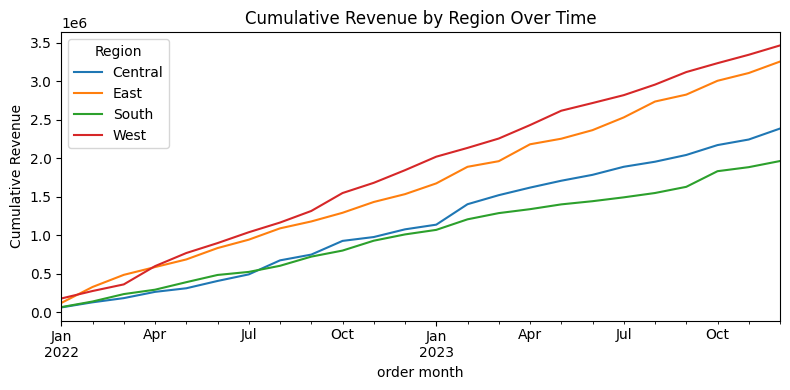

In [91]:
retail_orders.groupby(['order month', 'Region'])['revenue'].sum().groupby(level='Region').cumsum().unstack().plot(figsize=(8,4), title='Cumulative Revenue by Region Over Time')

plt.ylabel('Cumulative Revenue')
plt.tight_layout()
plt.show()

> **📊 Business Insight:** All four regions show consistent cumulative revenue growth over the 2-year period with no plateaus or declines — a positive indicator of business health. **West** and **East** pull ahead of Central and South in cumulative terms, reinforcing the regional profitability gap identified in Q2.1. The curves are relatively parallel, suggesting no single region is dramatically accelerating or decelerating relative to others.

### 6.3 Compare each order’s revenue against the regional average revenue using transform().


In [92]:
retail_orders['regional_avg_revenue'] = retail_orders.groupby('Region')['revenue'].transform('mean')

In [93]:
retail_orders['regional_vs_avg_revenue'] = retail_orders['revenue'] - retail_orders['regional_avg_revenue']

In [95]:
retail_orders[['Region', 'revenue', 'regional_avg_revenue', 'regional_vs_avg_revenue']].head(10)

,Region,revenue,regional_avg_revenue,regional_vs_avg_revenue
1665,Central,0.0,1027.929918,-1027.929918
4437,Central,85.5,1027.929918,-942.429918
6220,Central,137.2,1027.929918,-890.729918
6618,Central,144.0,1027.929918,-883.929918
9100,Central,2298.9,1027.929918,1270.970082
2187,Central,411.6,1027.929918,-616.329918
9225,Central,0.0,1027.929918,-1027.929918
9302,Central,28.5,1027.929918,-999.429918
8915,Central,38.4,1027.929918,-989.529918
9207,Central,116.4,1027.929918,-911.529918


> **📊 Business Insight:** Revenue within the Central region is heavily skewed — the regional average is $1,027.93, but the majority of individual orders fall well below this (most show large negative deviations). This confirms that Central's average is inflated by a small number of very high-value orders, while most orders are small-ticket. This pattern of high variance within regions is important context when evaluating regional performance.

## **7.  Pivoting, Reshaping & Aggregation**

### 7.1 Create a pivot table showing revenue by Region and Category.

In [96]:
pivot_revenue = pd.pivot_table(retail_orders, values='revenue', index='Region', columns='Category', aggfunc='sum').round(2)
pivot_revenue

Category,Furniture,Office Supplies,Technology
Region,,,
Central,789323.4,809910.7,788647.1
East,1061780.4,981628.6,1214574.8
South,623321.5,585073.7,757658.4
West,1246317.1,1047062.1,1174030.4


In [98]:
pivot_revenue = pd.pivot_table(
    retail_orders,
    values='revenue',
    index='Region',
    columns='Category',
    aggfunc='sum',
    margins=True,          # adds totals
    margins_name='Total'   # labels the total row/column
).round(2)

pivot_revenue

Category,Furniture,Office Supplies,Technology,Total
Region,,,,
Central,789323.4,809910.7,788647.1,2387881.2
East,1061780.4,981628.6,1214574.8,3257983.8
South,623321.5,585073.7,757658.4,1966053.6
West,1246317.1,1047062.1,1174030.4,3467409.6
Total,3720742.4,3423675.1,3934910.7,11079328.2


> **📊 Business Insight:** The pivot table reveals that **West dominates in both Furniture ($1.25M) and Office Supplies ($1.05M)**, while **East leads in Technology ($1.21M)**. The **South region consistently underperforms** across all three categories. Technology is the largest revenue driver in East and South, while Furniture leads in West — suggesting regional product preferences or sales focus may differ.

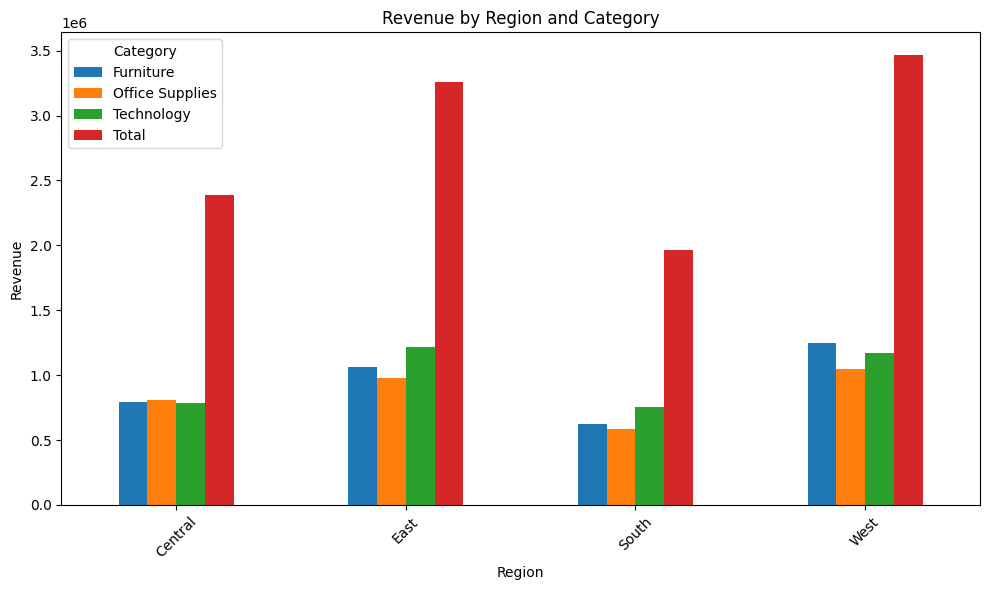

In [99]:
pivot_revenue.drop('Total').plot(
    kind='bar',
    figsize=(10, 6),
    title='Revenue by Region and Category'
)

plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.2 Convert the pivoted data back into a long-format DataFrame.

In [102]:
pivot_revenue_long = pivot_revenue.reset_index().melt(id_vars='Region', var_name='Category', value_name='revenue')
pivot_revenue_long

,Region,Category,revenue
0,Central,Furniture,789323.4
1,East,Furniture,1061780.4
2,South,Furniture,623321.5
3,West,Furniture,1246317.1
4,Total,Furniture,3720742.4
5,Central,Office Supplies,809910.7
6,East,Office Supplies,981628.6
7,South,Office Supplies,585073.7
8,West,Office Supplies,1047062.1
9,Total,Office Supplies,3423675.1


> **📊 Technical Note:** The long-format (melted) DataFrame restores the data to a structure suitable for further  operations, filtering, or visualization with tools like Seaborn. Note that the  row and column from  are included here — these should be filtered out before any further aggregation to avoid double-counting.

### 7.3 Build a category-level summary table with:

    Total revenue
    Total profit
    Average discount
    Order count

In [107]:
category_summary = (retail_orders.groupby('Category').agg(total_revenue=('revenue', 'sum'),
                                                          total_profit=('profit', 'sum'),
                                                          avg_discount=('Discount Percent', 'mean'),
                                                          order_count=('Order Id', 'count'))).round(3)
category_summary

,total_revenue,total_profit,avg_discount,order_count
Category,,,,
Furniture,3720742.4,342782.4,3.490,2121
Office Supplies,3423675.1,317425.1,3.478,6026
Technology,3934910.7,379720.7,3.496,1847


> **📊 Business Insight:** All three categories have nearly identical average discount rates (~3.49%), indicating discounting is applied uniformly across the business rather than being category-specific. Despite similar discounts, **Technology yields a higher profit per order** (379K profit / 1,847 orders = ~$205/order) compared to Office Supplies (~$53/order) — largely driven by the higher selling prices in Technology.

## **8. Time-Series Analysis**

### 8.1 What is the monthly revenue trend over time?

In [108]:
monthly_revenue = (retail_orders.groupby('order month').agg(total_revenue=('revenue', 'sum')).reset_index())

monthly_revenue

,order month,total_revenue
0,2022-01,437431.3
1,2022-02,444011.1
2,2022-03,394105.2
3,2022-04,476400.9
4,2022-05,413625.5
5,2022-06,465300.3
6,2022-07,375278.4
7,2022-08,534562.4
8,2022-09,433887.0
9,2022-10,601707.8


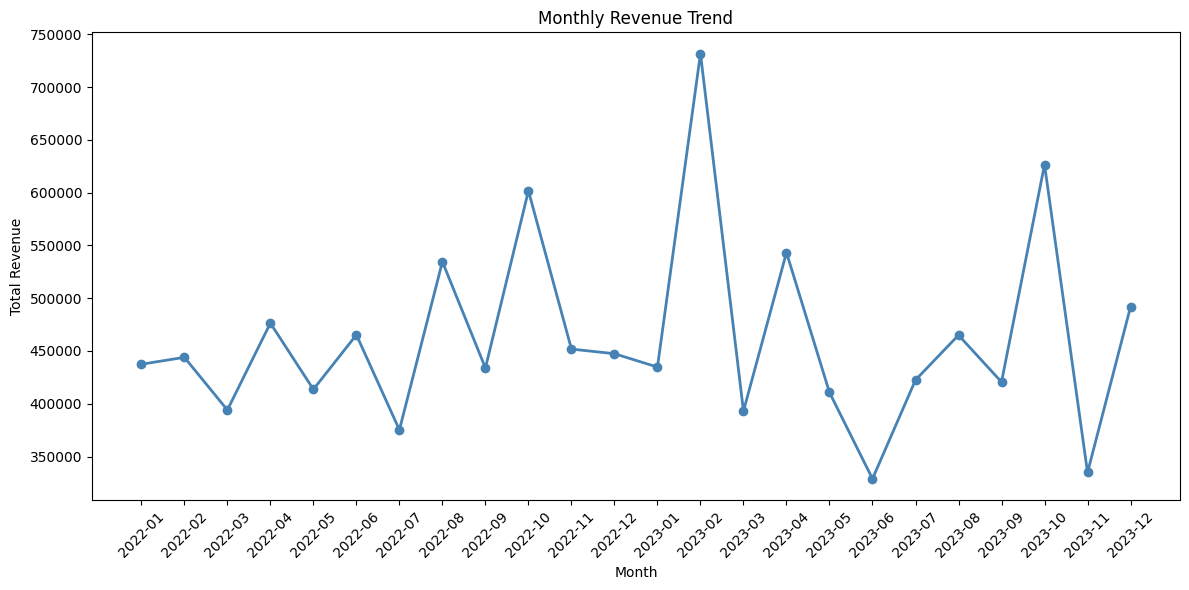

In [109]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['order month'].astype(str),
    monthly_revenue['total_revenue'],
    marker='o',
    linewidth=2,
    color='steelblue'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.2 Calculate month-over-month revenue growth percentage.

> **📊 Business Insight:** Monthly revenue ranges from ~$328K (June 2023, lowest) to ~$731K (February 2023, highest). There is no clear smooth upward trend — instead, revenue is volatile month-to-month. **Q4 months (Oct-Dec)** tend to be stronger, consistent with typical retail seasonality patterns. The business does not appear to have strong linear growth over the 2-year period.

In [110]:
monthly_revenue['MoM'] = (monthly_revenue['total_revenue'].pct_change() * 100).round(2)
monthly_revenue

,order month,total_revenue,MoM
0,2022-01,437431.3,NaN
1,2022-02,444011.1,1.50
2,2022-03,394105.2,-11.24
3,2022-04,476400.9,20.88
4,2022-05,413625.5,-13.18
5,2022-06,465300.3,12.49
6,2022-07,375278.4,-19.35
7,2022-08,534562.4,42.44
8,2022-09,433887.0,-18.83
9,2022-10,601707.8,38.68


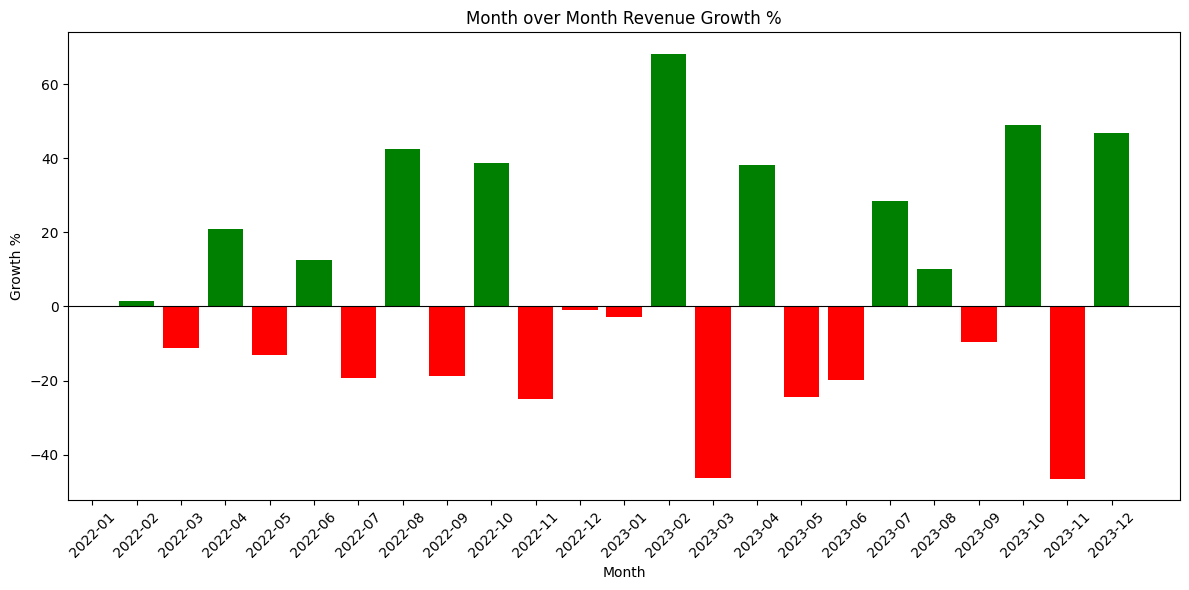

In [112]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_revenue['order month'].astype(str),
    monthly_revenue['MoM'],
    color=monthly_revenue['MoM'].apply(
        lambda x: 'green' if x > 0 else 'red'
    )
)

plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Month over Month Revenue Growth %')
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **📊 Business Insight:** Month-over-month growth is extremely volatile, swinging from **+68.28% (Jan→Feb 2023)** to **-46.54% (Oct→Nov 2023)**. This level of volatility suggests the business may be heavily influenced by a few large orders each month rather than steady organic growth. The largest positive spike in Feb 2023 and subsequent crash in Mar 2023 (-46.28%) warrants investigation into whether a single bulk order caused that anomaly.

### 8.3 Identify months with declining revenue and investigate possible causes.

In [113]:
declining_months = (
    monthly_revenue[monthly_revenue["MoM"] < 0].sort_values('MoM')
)

By Region — did all regions decline or just some?

In [114]:
retail_orders.groupby(['order month', 'Region'])['revenue'].sum().unstack()

Region,Central,East,South,West
order month,,,,
2022-01,64896.3,122995.2,68703.6,180836.2
2022-02,66365.5,207385.1,73053.7,97206.8
2022-03,54406.8,157488.0,96287.6,85922.8
2022-04,81259.4,100991.3,57020.2,237130.0
2022-05,46654.2,99143.2,97621.3,170206.8
2022-06,94893.3,147659.4,93722.4,129025.2
2022-07,85454.9,109179.9,39689.1,140954.5
2022-08,182196.1,146930.6,79560.6,125875.1
2022-09,74847.8,89693.1,118917.2,150428.9


By Category — which category dragged revenue down?

In [115]:
retail_orders.groupby(['order month', 'Category'])['revenue'].sum().unstack()

Category,Furniture,Office Supplies,Technology
order month,,,
2022-01,170244.5,150070.3,117116.5
2022-02,192062.9,158455.0,93493.2
2022-03,150128.1,123219.2,120757.9
2022-04,162806.9,198846.3,114747.7
2022-05,110578.8,132074.4,170972.3
2022-06,159075.8,123805.6,182418.9
2022-07,137750.0,134712.3,102816.1
2022-08,162276.8,127248.0,245037.6
2022-09,107151.9,152259.1,174476.0


By Discount — did discounting increase that month?


In [116]:
retail_orders.groupby('order month')['Discount Percent'].mean().round(2)

order month
2022-01    3.37
2022-02    3.51
2022-03    3.49
2022-04    3.54
2022-05    3.50
2022-06    3.52
2022-07    3.48
2022-08    3.51
2022-09    3.41
2022-10    3.42
2022-11    3.48
2022-12    3.52
2023-01    3.60
2023-02    3.49
2023-03    3.50
2023-04    3.44
2023-05    3.46
2023-06    3.50
2023-07    3.38
2023-08    3.48
2023-09    3.57
2023-10    3.49
2023-11    3.55
2023-12    3.44
Freq: M, Name: Discount Percent, dtype: float64

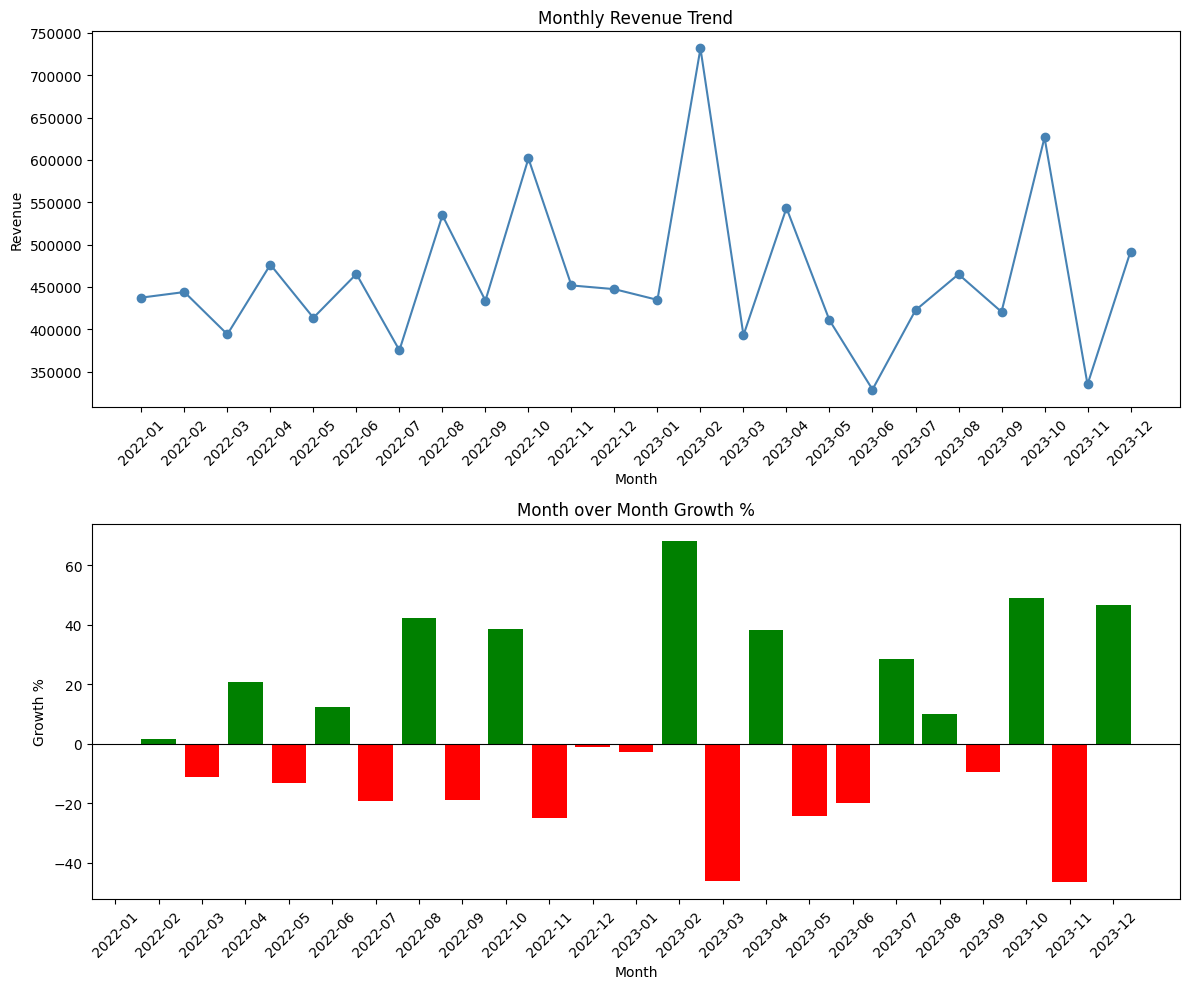

In [118]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1 — Monthly revenue with declining months highlighted
axes[0].plot(
    monthly_revenue['order month'].astype(str),
    monthly_revenue['total_revenue'],
    marker='o',
    color='steelblue'
)
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 — MoM growth with red bars for declining months
axes[1].bar(
    monthly_revenue['order month'].astype(str),
    monthly_revenue['MoM'],
    color=monthly_revenue['MoM'].apply(
        lambda x: 'green' if x > 0 else 'red'
    )
)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Month over Month Growth %')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Growth %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **📊 Business Insight:** Revenue declines are spread across both years with no seasonal pattern in the declining months. Importantly, **discount rates remain nearly constant across all months (3.37%-3.60%)**, ruling out discounting as a cause of revenue dips. Declines appear to be driven by **regional and category-level volatility** rather than any single systemic cause — for example, June 2023's decline is visible across all regions and categories simultaneously, suggesting a broader demand dip that month.

## **9. Data Quality & Performance Mindset**

### 9.1 Validate that no orders have negative revenue or invalid profit margins.

In [119]:
# Check 1 — Negative revenue
negative_revenue = retail_orders[retail_orders['revenue'] < 0]
print(f"Orders with negative revenue: {len(negative_revenue)}")

# Check 2 — Null values in key columns
null_check = retail_orders[['revenue', 'profit', 'profit_margin']].isnull().sum()
print(f"\nNull values:\n{null_check}")

# Check 3 — Invalid profit margins (outside -100 to 100 range)
invalid_margins = retail_orders[
    (retail_orders['profit_margin'] < -100) | 
    (retail_orders['profit_margin'] > 100)
]
print(f"\nOrders with invalid profit margins: {len(invalid_margins)}")

# Check 4 — Zero revenue orders (suspicious)
zero_revenue = retail_orders[retail_orders['revenue'] == 0]
print(f"\nOrders with zero revenue: {len(zero_revenue)}")

Orders with negative revenue: 0

Null values:
revenue            0
profit             0
profit_margin    507
dtype: int64

Orders with invalid profit margins: 0

Orders with zero revenue: 507


In [120]:
retail_orders['profit_margin'] = retail_orders['profit_margin'].fillna(0)
print(retail_orders['profit_margin'].isnull().sum())

0


> **📊 Data Quality Finding:** The validation revealed **507 null profit margins** — all caused by zero-revenue orders (division by zero). There are **no negative revenue orders** and **no invalid margins** outside the -100 to +100 range. The nulls were cleanly resolved by filling with 0. Overall the dataset is in good shape for SQL loading, with only the zero-revenue orders (likely cancelled/free orders) worth flagging as a data quality note.

### 9.2 Optimize memory usage by converting suitable columns to categorical types.

In [121]:
retail_orders.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1665 to 7862
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Id                 9994 non-null   int64         
 1   Order Date               9994 non-null   datetime64[ns]
 2   Ship Mode                9993 non-null   object        
 3   Segment                  9994 non-null   object        
 4   Country                  9994 non-null   object        
 5   City                     9994 non-null   object        
 6   State                    9994 non-null   object        
 7   Postal Code              9994 non-null   int64         
 8   Region                   9994 non-null   object        
 9   Category                 9994 non-null   object        
 10  Sub Category             9994 non-null   object        
 11  Product Id               9994 non-null   object        
 12  cost price               9994 non-nu

In [122]:
for col in retail_orders.select_dtypes(include='object').columns:
    print(f"{col}: {retail_orders[col].nunique()} unique values")

Ship Mode: 6 unique values
Segment: 3 unique values
Country: 1 unique values
City: 531 unique values
State: 49 unique values
Region: 4 unique values
Category: 3 unique values
Sub Category: 17 unique values
Product Id: 1862 unique values
profit_label: 4 unique values
shipping_priority: 4 unique values
order_segment: 2 unique values


In [123]:
cat_columns = [
    'Region', 
    'Category', 
    'Sub Category',
    'Ship Mode', 
    'Segment',
    'profit_label',
    'shipping_priority',
    'order_segment'
]

for col in cat_columns:
    retail_orders[col] = retail_orders[col].astype('category')

In [124]:
retail_orders.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1665 to 7862
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Id                 9994 non-null   int64         
 1   Order Date               9994 non-null   datetime64[ns]
 2   Ship Mode                9993 non-null   category      
 3   Segment                  9994 non-null   category      
 4   Country                  9994 non-null   object        
 5   City                     9994 non-null   object        
 6   State                    9994 non-null   object        
 7   Postal Code              9994 non-null   int64         
 8   Region                   9994 non-null   category      
 9   Category                 9994 non-null   category      
 10  Sub Category             9994 non-null   category      
 11  Product Id               9994 non-null   object        
 12  cost price               9994 non-nu

> **📊 Performance Insight:** Converting 8 columns to categorical dtype reduced memory usage from **9.1 MB to 4.2 MB** — a **54% reduction**. This is because categorical columns store each unique value only once and use integer codes internally, rather than storing the full string for every row. For large production datasets with millions of rows, this optimization becomes critical for both memory efficiency and query performance in downstream SQL/BI tools.